# Pertanyaan Bisnis

- Apakah faktor demografis seperti jenis kelamin, usia, pendidikan terakhir, dan status pernikahan memengaruhi tingkat burnout karyawan?
- Bagaimana departemen, tipe perusahaan, status WFH, dan lama bekerja memengaruhi tingkat burnout karyawan?
- Apakah jam kerja, jam lembur, frekuensi meeting, jumlah deadline, konflik kerja, dan persepsi beban kerja berkaitan dengan meningkatnya burnout karyawan?
- Bagaimana pola tidur, olahraga, penggunaan layar, dan kebiasaan merokok memengaruhi tingkat burnout karyawan?
- Bagaimana tingkat stres, kepuasan kerja, work-life balance, produktivitas diri, dukungan atasan, dan keamanan pekerjaan memengaruhi tingkat burnout karyawan?
- Apakah riwayat kesehatan mental dan keluhan fisik utama berkaitan dengan tingkat burnout karyawan?

# Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# Data Wrangling

## Gathering Data

Gathering data adalah proses mengumpulkan data yang digunakan untuk menjawab pertanyaan bisnis.

In [2]:
df = pd.read_csv("dataAIBaru.csv")
df.head()

,employee_id,jenis_kelamin,usia,pendidikan_terakhir,status_pernikahan,departemen,lama_bekerja_tahun,tipe_perusahaan,status_wfh,jam_kerja_per_hari,...,dukungan_atasan,frekuensi_meeting_per_hari,jumlah_deadline_per_minggu,beban_kerja_persepsi,status_merokok,riwayat_kesehatan_mental,keluhan_fisik_utama,keamanan_pekerjaan,frekuensi_konflik_kerja,tingkat_burnout_label
0,EMP02226,Perempuan,35.0,D3,Menikah,Marketing,3.0,Corporate,Hybrid,8.3,...,7.2,1.0,1.0,Sangat Ringan,Ya,Tidak Ada,Tidak Ada,Aman,3.3,Low
1,EMP00278,Laki-laki,31.0,S2,Menikah,HR,5.3,Corporate,Ya,6.5,...,5.7,1.0,2.0,Ringan,Tidak,Pernah Depresi,Tidak Ada,Sangat Aman,2.2,Low
2,EMP14802,Laki-laki,33.0,S2,Menikah,Engineering,4.0,BUMN,Ya,7.8,...,6.9,1.0,1.0,Ringan,Kadang,Tidak Ada,Tidak Ada,Aman,2.0,Low
3,EMP12467,Laki-laki,37.0,SMA/SMK,Menikah,Operations,1.3,BUMN,Tidak,12.9,...,5.8,6.0,4.0,Sedang,Kadang,Kecemasan,Mata Lelah,NaN,6.3,High
4,EMP09253,Laki-laki,25.0,S2,Belum Menikah,Finance,NaN,Freelance,Tidak,8.1,...,4.8,3.0,3.0,Berat,Tidak,Pernah Depresi,Tidak Ada,Cukup Aman,2.5,Medium


## Assessing Data

Assessing data adalah proses untuk menilai kualitas dan struktur dari dataset yang digunakan.

1. Memeriksa tipe data dari tiap kolom yang terdapat di dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   employee_id                    18000 non-null  object
 1   jenis_kelamin                  17770 non-null  object
 2   usia                           17731 non-null  object
 3   pendidikan_terakhir            17791 non-null  object
 4   status_pernikahan              17801 non-null  object
 5   departemen                     17762 non-null  object
 6   lama_bekerja_tahun             17713 non-null  object
 7   tipe_perusahaan                17789 non-null  object
 8   status_wfh                     17807 non-null  object
 9   jam_kerja_per_hari             17702 non-null  object
 10  jam_lembur_per_hari            17713 non-null  object
 11  jam_tidur_per_hari             17705 non-null  object
 12  kualitas_tidur                 17724 non-null  object
 13  f

2. Memeriksa apakah terdapat missing value di tiap kolom pada dataset.

In [4]:
df.isna().sum()

employee_id                        0
jenis_kelamin                    230
usia                             269
pendidikan_terakhir              209
status_pernikahan                199
departemen                       238
lama_bekerja_tahun               287
tipe_perusahaan                  211
status_wfh                       193
jam_kerja_per_hari               298
jam_lembur_per_hari              287
jam_tidur_per_hari               295
kualitas_tidur                   276
frekuensi_olahraga_per_minggu    288
jam_layar_per_hari               286
tingkat_stres                    289
kepuasan_kerja                   305
work_life_balance                276
produktivitas_diri               284
dukungan_atasan                  245
frekuensi_meeting_per_hari       286
jumlah_deadline_per_minggu       287
beban_kerja_persepsi             229
status_merokok                   213
riwayat_kesehatan_mental         251
keluhan_fisik_utama              201
keamanan_pekerjaan               219
f

3. Memeriksa apakah terdapat data yang duplikat di tiap kolom ada dataset.

In [5]:
df.duplicated().sum()

np.int64(0)

4. Memeriksa parameter statistik dari kolom yang terdapat di dataset.

In [6]:
df.describe()

,employee_id,jenis_kelamin,usia,pendidikan_terakhir,status_pernikahan,departemen,lama_bekerja_tahun,tipe_perusahaan,status_wfh,jam_kerja_per_hari,...,dukungan_atasan,frekuensi_meeting_per_hari,jumlah_deadline_per_minggu,beban_kerja_persepsi,status_merokok,riwayat_kesehatan_mental,keluhan_fisik_utama,keamanan_pekerjaan,frekuensi_konflik_kerja,tingkat_burnout_label
count,18000,17770,17731,17791,17801,17762,17713,17789,17807,17702,...,17755,17714,17713,17771,17787,17749,17799,17781,17725,18000
unique,18000,6,121,8,6,25,275,14,9,194,...,185,91,83,15,9,9,15,15,199,3
top,EMP13092,Laki-laki,30.0,S1,Belum Menikah,Engineering,0.1,Corporate,Ya,8.8,...,5.6,3.0,2.0,Sedang,Tidak,Tidak Ada,Tidak Ada,Cukup Aman,1.0,Low
freq,1,10582,1160,7543,8948,2000,854,3597,7133,319,...,332,3670,3558,5664,10558,12317,7352,5919,1302,6000


## Cleaning Data

Cleaning data adalah proses untuk membersihkan data dari masalah yang ditemukan di proses sebelumnya.

1. Menghapus baris duplikat.

In [7]:
# hapus baris duplikat
df = df.drop_duplicates()
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 0


2. Drop kolom tidak dipakai yaitu kolom employee_id.

In [8]:
# drop kolom tidak dipakai
df = df.drop(columns=['employee_id'])
df.head()

,jenis_kelamin,usia,pendidikan_terakhir,status_pernikahan,departemen,lama_bekerja_tahun,tipe_perusahaan,status_wfh,jam_kerja_per_hari,jam_lembur_per_hari,...,dukungan_atasan,frekuensi_meeting_per_hari,jumlah_deadline_per_minggu,beban_kerja_persepsi,status_merokok,riwayat_kesehatan_mental,keluhan_fisik_utama,keamanan_pekerjaan,frekuensi_konflik_kerja,tingkat_burnout_label
0,Perempuan,35.0,D3,Menikah,Marketing,3.0,Corporate,Hybrid,8.3,0.0,...,7.2,1.0,1.0,Sangat Ringan,Ya,Tidak Ada,Tidak Ada,Aman,3.3,Low
1,Laki-laki,31.0,S2,Menikah,HR,5.3,Corporate,Ya,6.5,0.6,...,5.7,1.0,2.0,Ringan,Tidak,Pernah Depresi,Tidak Ada,Sangat Aman,2.2,Low
2,Laki-laki,33.0,S2,Menikah,Engineering,4.0,BUMN,Ya,7.8,0.2,...,6.9,1.0,1.0,Ringan,Kadang,Tidak Ada,Tidak Ada,Aman,2.0,Low
3,Laki-laki,37.0,SMA/SMK,Menikah,Operations,1.3,BUMN,Tidak,12.9,4.3,...,5.8,6.0,4.0,Sedang,Kadang,Kecemasan,Mata Lelah,NaN,6.3,High
4,Laki-laki,25.0,S2,Belum Menikah,Finance,NaN,Freelance,Tidak,8.1,2.2,...,4.8,3.0,3.0,Berat,Tidak,Pernah Depresi,Tidak Ada,Cukup Aman,2.5,Medium


3. Mengganti noise menjadi nan

In [9]:
#mengganti noise menjadi nan
NOISE = {"-", "?", "tidak tahu", "Tidak Tahu", ""}

def to_nan(series):
    """Ganti nilai noise → NaN."""
    return series.apply(lambda x: np.nan if str(x).strip() in NOISE else x)

4. Standarisasi kolom jenis kelamin menjadi Laki-laki dan Perempuan.

In [10]:
# standarisasi kolom jenis kelamin
def std_gender(x):
    if pd.isna(x): return np.nan
    v = str(x).strip().lower()
    if v in {"l","laki","laki-laki","pria","male","cowo","lk"}: return "Laki-laki"
    if v in {"p","perempuan","wanita","female","cewe","pr"}:    return "Perempuan"
    return np.nan
df["jenis_kelamin"] = to_nan(df["jenis_kelamin"]).apply(std_gender)

5. Standarisasi kolom pendidikan terakhir menjadi SD, SMP, SMA D3, S1, S2, dan S3.

In [11]:
# standarisasi kolom pendidikan terakhir
def std_edu(x):
    if pd.isna(x): return np.nan
    v = str(x).strip().lower().replace("-","").replace(" ","")
    m = {"sd":"SD","smp":"SMP","sma":"SMA","smk":"SMA","smasmk":"SMA",
         "d3":"D3","diploma3":"D3","s1":"S1","sarjana":"S1",
         "s2":"S2","magister":"S2","s3":"S3","doktor":"S3"}
    return m.get(v, np.nan)
df["pendidikan_terakhir"] = to_nan(df["pendidikan_terakhir"]).apply(std_edu)

6. Standarisasi kolom status pernikahan menjadi Belum Menikah, Menikah, dan Cerai/Duda/Janda.

In [12]:
# standarisasi kolom status pernikahan
def std_marital(x):
    if pd.isna(x): return np.nan
    v = str(x).strip().lower()
    if v in {"belum menikah","lajang","single"}:                    return "Belum Menikah"
    if v in {"menikah","married"}:                                   return "Menikah"
    if v in {"cerai","divorced","duda","janda","duda/janda"}:        return "Cerai/Duda/Janda"
    return np.nan
df["status_pernikahan"] = to_nan(df["status_pernikahan"]).apply(std_marital)

7. Standarisasi kolom tipe perusahaan menjadi Swasta, BUMN, Startup, dan Freelance.

In [13]:
# standarisasi kolom tipe perusahaan
def std_company(x):
    if pd.isna(x): return np.nan
    v = str(x).strip().lower()
    m = {"swasta":"Swasta","corporate":"Swasta","korporat":"Swasta",
         "bumn":"BUMN","badan usaha milik negara":"BUMN",
         "startup":"Startup","freelance":"Freelance"}
    return m.get(v, np.nan)
df["tipe_perusahaan"] = to_nan(df["tipe_perusahaan"]).apply(std_company)

8. Standarisasi kolom status wfh menjadi Ya, Tidak, dan Hybrid.

In [14]:
# standarisasi kolom status wfh
def std_wfh(x):
    if pd.isna(x): return np.nan
    v = str(x).strip().lower()
    if v in {"ya","y","yes","iya"}:                                          return "Ya"
    if v in {"tidak","t","no","nope"}:                                       return "Tidak"
    if v in {"hybrid","campuran","kadang","tergantung","wfh & wfo","wfh&wfo"}: return "Hybrid"
    return np.nan
df["status_wfh"] = to_nan(df["status_wfh"]).apply(std_wfh)

9. Standarisasi kolom beban kerja persepsi menjadi Ringan, Sedang, Berat, dan Sangat Berat.

In [15]:
# standarisasi kolom beban kerja persepsi
def std_workload(x):
    if pd.isna(x): return np.nan
    v = str(x).strip().lower()
    if v in {"ringan","sangat ringan","normal"}:     return "Ringan"
    if v in {"sedang","medium"}:                     return "Sedang"
    if v in {"berat","heavy","tinggi","overload"}:   return "Berat"
    if v in {"sangat berat","overwhelmed"}:          return "Sangat Berat"
    return np.nan
df["beban_kerja_persepsi"] = to_nan(df["beban_kerja_persepsi"]).apply(std_workload)

10. Standarisasi kolom status merokok menjadi Ya, Tidak, dan Kadang.

In [16]:
# standarisasi kolom status merokok
def std_smoke(x):
    if pd.isna(x): return np.nan
    v = str(x).strip().lower()
    if v in {"ya","yes","iya","merokok"}:        return "Ya"
    if v in {"tidak","no","tidak merokok"}:      return "Tidak"
    if v in {"kadang","social smoker","sosial"}: return "Kadang"
    return np.nan
df["status_merokok"] = to_nan(df["status_merokok"]).apply(std_smoke)

11. Standarisasi kolom keamanan pekerjaan menjadi Tidak Aman, Cukup Aman, Aman, dan Sangat Aman.

In [17]:
# standarisasi kolom keamanan pekerjaan
def std_job_sec(x):
    if pd.isna(x): return np.nan
    v = str(x).strip().lower()
    m = {"sangat tidak aman":"Sangat Tidak Aman","tidak aman":"Tidak Aman",
         "khawatir":"Tidak Aman","sangat khawatir":"Sangat Tidak Aman",
         "netral":"Cukup Aman","cukup aman":"Cukup Aman",
         "aman":"Aman","sangat aman":"Sangat Aman"}
    return m.get(v, np.nan)
df["keamanan_pekerjaan"] = to_nan(df["keamanan_pekerjaan"]).apply(std_job_sec)

12. Standarisasi kolom departemen, keluhan fisik utama, dan riwayat kesehatan mental.

In [18]:
# standarisasi kolom departemen, keluhan fisik utama, dan riwayat kesehatan mental
for col in ["departemen","keluhan_fisik_utama","riwayat_kesehatan_mental"]:
    df[col] = to_nan(df[col]).str.strip().str.title()

13. Standarisasi semua kolom numerik dengan memberikan batas minimal dan maksimal di tiap kolomnya.

In [19]:
# standarisasi kolom numerik
# Batas logis per kolom (min, max)
numeric_bounds = {
    "usia"                          : (15,  70),
    "lama_bekerja_tahun"            : (0,   50),
    "jam_kerja_per_hari"            : (0,   24),
    "jam_lembur_per_hari"           : (0,   16),
    "jam_tidur_per_hari"            : (0,   24),
    "kualitas_tidur"                : (0,   10),
    "frekuensi_olahraga_per_minggu" : (0,   14),
    "jam_layar_per_hari"            : (0,   24),
    "tingkat_stres"                 : (0,   10),
    "kepuasan_kerja"                : (0,   10),
    "work_life_balance"             : (0,   10),
    "produktivitas_diri"            : (0,   10),
    "dukungan_atasan"               : (0,   10),
    "frekuensi_meeting_per_hari"    : (0,   20),
    "jumlah_deadline_per_minggu"    : (0,   50),
    "frekuensi_konflik_kerja"       : (0,   10),
}

for col, (lo, hi) in numeric_bounds.items():
    df[col] = (
        pd.to_numeric(df[col], errors="coerce")   # konversi, error → NaN
        .clip(lower=lo, upper=hi)                  # buang outlier tidak logis
        .round(0)                                  # bulatkan ke bilangan bulat
        .astype("Int64")                           # simpan sebagai integer (support NaN)
    )


14. Mengatasi missing value untuk kolom numerik, dikonversi menggunakan median.

In [20]:
# mengatasi missing value untuk kolom numerik (dikonversi menggunakan median)
for col in [c for c in numeric_bounds if c != "tingkat_burnout_label"]:
    if df[col].isna().any():
        median_val = int(df[col].dropna().median())
        df[col] = df[col].fillna(median_val)

15. Mengatasi missing value untuk kolom kategorikal, dikonversi menggunakan modus.

In [21]:
# mengatasi missing value untuk kolom kategorikal (dikonversi menggunakan modus)
cat_cols = [
    "jenis_kelamin","pendidikan_terakhir","status_pernikahan",
    "departemen", "tipe_perusahaan", "status_wfh", "beban_kerja_persepsi",
    "status_merokok", "keluhan_fisik_utama","riwayat_kesehatan_mental","keamanan_pekerjaan",
]
for col in cat_cols:
    if df[col].isna().any():
        mode_val = df[col].mode()
        if len(mode_val) > 0:
            df[col] = df[col].fillna(mode_val[0])

16. Menyimpan data bersih.

In [22]:
# menyimpan data bersih
df.to_csv("dataAIBaru_cleaned.csv", index=False)
print("\nFile tersimpan: dataAIBaru_cleaned.csv")
print(f"Total baris: {len(df)} | Total kolom: {df.shape[1]}")


File tersimpan: dataAIBaru_cleaned.csv
Total baris: 18000 | Total kolom: 28


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis adalah proses untuk memperoleh insight dan menjawab pertanyaan bisnis.

1. Mengubah label pada kolom burnout menjadi numerik untuk proses EDA.

In [23]:
# Mengubah label burnout menjadi numerik
burnout_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df['tingkat_burnout'] = df['tingkat_burnout_label'].map(burnout_mapping)

### EDA untuk pertanyaan bisnis 1 : Apakah faktor demografis seperti jenis kelamin, usia, pendidikan terakhir, dan status pernikahan memengaruhi tingkat burnout karyawan?

1. Menghitung rata-rata burnout berdasarkan jenis kelamin.

In [24]:
# Menghitung rata-rata burnout berdasarkan jenis kelamin
gender_burnout = df.groupby('jenis_kelamin')['tingkat_burnout'].mean().reset_index()

# Mengurutkan dari burnout tertinggi
gender_burnout = gender_burnout.sort_values(
    by='tingkat_burnout',
    ascending=False
)

print("Rata-rata burnout berdasarkan jenis kelamin:")
print(gender_burnout)

Rata-rata burnout berdasarkan jenis kelamin:
  jenis_kelamin  tingkat_burnout
0     Laki-laki         2.005506
1     Perempuan         1.991552


2. Menghitung rata-rata burnout berdasarkan umur.

In [25]:
age_burnout = df.groupby('usia')['tingkat_burnout'].mean().reset_index()

age_burnout = age_burnout.sort_values(
    by='tingkat_burnout',
    ascending=False
)

print("\nRata-rata burnout berdasarkan pendidikan:")
print(age_burnout)


Rata-rata burnout berdasarkan pendidikan:
    usia  tingkat_burnout
34    63         2.333333
24    42         2.170455
27    45         2.071429
36    70         2.049383
17    35         2.039017
16    34         2.033943
19    37         2.033816
11    29         2.032100
1     19         2.026087
12    30         2.023276
0     18         2.014688
20    38         2.014045
9     27         2.013599
18    36         2.003630
6     24         2.003311
29    47         2.000000
31    49         2.000000
30    48         2.000000
14    32         1.999006
21    39         1.991489
8     26         1.987215
7     25         1.987000
4     22         1.986047
25    43         1.985507
13    31         1.985337
15    33         1.982418
10    28         1.976555
23    41         1.964539
2     20         1.961538
3     21         1.961062
5     23         1.950685
26    44         1.923077
22    40         1.910000
28    46         1.583333
32    50         1.333333
33    52         1.00

3. Menghitung rata-rata burnout berdasarkan tingkat pendidikan terakhir.

In [26]:
education_burnout = df.groupby('pendidikan_terakhir')['tingkat_burnout'].mean().reset_index()

education_burnout = education_burnout.sort_values(
    by='tingkat_burnout',
    ascending=False
)

print("\nRata-rata burnout berdasarkan pendidikan:")
print(education_burnout)


Rata-rata burnout berdasarkan pendidikan:
  pendidikan_terakhir  tingkat_burnout
2                  S2         2.007483
0                  D3         2.002010
1                  S1         1.995879


4. Menghitung rata-rata burnout berdasarkan status pernikahan.

In [27]:
marital_burnout = df.groupby('status_pernikahan')['tingkat_burnout'].mean().reset_index()

marital_burnout = marital_burnout.sort_values(
    by='tingkat_burnout',
    ascending=False
)

print(marital_burnout)

  status_pernikahan  tingkat_burnout
0     Belum Menikah         2.009552
1           Menikah         1.989985


- Insight pertanyaan bisnis 1:
1. Karyawan laki-laki memiliki rata-rata burnout sedikit lebih tinggi dibandingkan perempuan. Perbedaannya tidak terlalu besar, sehingga dapat disimpulkan bahwa gender bukan faktor utama yang memengaruhi burnout pada dataset ini. Namun, laki-laki cenderung mengalami tekanan kerja sedikit lebih tinggi.
2. Kelompok usia tertentu memiliki tingkat burnout lebih tinggi dibanding usia lainnya. Hal ini menunjukkan bahwa burnout cenderung lebih tinggi pada usia produktif dan usia menjelang senior, kemungkinan karena tekanan pekerjaan, tanggung jawab, dan beban kerja yang lebih besar. Namun, beberapa usia ekstrem memiliki jumlah data yang kemungkinan sedikit sehingga nilainya bisa kurang stabil.
3. Tingkat pendidikan menunjukkan perbedaan burnout yang sangat kecil. Hal ini menunjukkan bahwa tingkat pendidikan tidak memiliki pengaruh signifikan terhadap burnout. Burnout tampaknya lebih dipengaruhi oleh kondisi kerja dibanding latar belakang pendidikan.
4. Karyawan yang belum menikah memiliki tingkat burnout sedikit lebih tinggi dibandingkan yang sudah menikah. Hal ini dapat mengindikasikan bahwa dukungan sosial atau emosional dari pasangan membantu menurunkan tingkat burnout. Namun, selisihnya juga relatif kecil sehingga pengaruhnya tidak terlalu dominan.
5. Faktor demografis memiliki pengaruh terhadap burnout, tetapi tidak terlalu kuat. Usia menjadi faktor yang paling terlihat memengaruhi burnout dibanding gender, pendidikan, dan status pernikahan.

### EDA untuk pertanyaan bisnis 2 : Bagaimana departemen, tipe perusahaan, status WFH, dan lama bekerja memengaruhi tingkat burnout karyawan?

1. Menghitung rata-rata burnout berdasarkan departemen di perusahaan.

In [28]:
department_burnout = df.groupby('departemen')['tingkat_burnout'].mean().reset_index()

department_burnout = department_burnout.sort_values(
    by='tingkat_burnout',
    ascending=False
)

print("Rata-rata burnout berdasarkan departemen:")
print(department_burnout)

Rata-rata burnout berdasarkan departemen:
    departemen  tingkat_burnout
3           Hr         2.033400
5    Marketing         2.017923
2      Finance         2.011558
0         Data         2.003507
8        Sales         1.996967
1  Engineering         1.996455
4           It         1.987552
6   Operations         1.980473
7      Product         1.972527


2. Menghitung rata-rata burnout berdasarkan tipe perusahaan.

In [29]:
company_burnout = df.groupby('tipe_perusahaan')['tingkat_burnout'].mean().reset_index()

company_burnout = company_burnout.sort_values(
    by='tingkat_burnout',
    ascending=False
)

print("\nRata-rata burnout berdasarkan tipe perusahaan:")
print(company_burnout)


Rata-rata burnout berdasarkan tipe perusahaan:
  tipe_perusahaan  tingkat_burnout
2         Startup         2.020460
1       Freelance         2.000000
3          Swasta         1.994081
0            BUMN         1.992188


3. Menghitung rata-rata burnout berdasarkan status WFH.

In [30]:
wfh_burnout = df.groupby('status_wfh')['tingkat_burnout'].mean().reset_index()

print("\nRata-rata burnout berdasarkan status WFH:")
print(wfh_burnout)


Rata-rata burnout berdasarkan status WFH:
  status_wfh  tingkat_burnout
0     Hybrid         2.003095
1      Tidak         2.004951
2         Ya         1.993764


4. Menghitung rata-rata burnout berdasarkan lama bekerja dalam tahun di perusahaan.

In [31]:
work_year_burnout = df.groupby('lama_bekerja_tahun')['tingkat_burnout'].mean().reset_index()

print("\nRata-rata burnout berdasarkan lama bekerja:")
print(work_year_burnout)


Rata-rata burnout berdasarkan lama bekerja:
    lama_bekerja_tahun  tingkat_burnout
0                    0         2.012500
1                    1         1.997423
2                    2         1.992450
3                    3         2.022222
4                    4         1.970464
5                    5         1.991786
6                    6         2.018203
7                    7         2.013566
8                    8         1.982103
9                    9         1.912879
10                  10         2.040909
11                  11         2.013605
12                  12         1.992424
13                  13         2.055556
14                  14         2.084507
15                  15         2.052632
16                  16         2.054054
17                  17         2.000000
18                  18         1.875000
19                  19         2.214286
20                  20         1.821429
21                  21         1.000000
22                  22         2.00

- Insight pertanyaan bisnis 2:
1. Beberapa departemen memiliki rata-rata burnout lebih tinggi dibandingkan departemen lainnya. Hal ini menunjukkan bahwa departemen yang berhubungan dengan pengelolaan manusia, target bisnis, dan tekanan administratif cenderung memiliki tingkat burnout lebih tinggi. Sementara departemen seperti Product dan Operations memiliki burnout lebih rendah, kemungkinan karena pembagian kerja yang lebih stabil atau fleksibel.
2. Karyawan di perusahaan startup memiliki tingkat burnout tertinggi dibanding tipe perusahaan lainnya. Hal ini menunjukkan bahwa lingkungan startup cenderung memberikan tekanan kerja lebih tinggi, seperti target cepat, jam kerja fleksibel namun panjang, dan tuntutan multitasking. Sebaliknya, perusahaan BUMN dan swasta memiliki burnout sedikit lebih rendah karena struktur kerja yang cenderung lebih stabil.
3. Perbedaan burnout berdasarkan status kerja tidak terlalu besar, tetapi terdapat pola menarik. Karyawan yang bekerja penuh dari rumah memiliki burnout paling rendah dibandingkan model kerja lainnya.
Hal ini menunjukkan bahwa fleksibilitas kerja dapat membantu mengurangi tekanan kerja dan meningkatkan kenyamanan kerja. Sementara karyawan yang bekerja langsung di kantor memiliki burnout sedikit lebih tinggi, kemungkinan karena faktor perjalanan, tekanan sosial, atau lingkungan kerja yang lebih melelahkan.
4. Burnout cenderung meningkat pada beberapa kelompok masa kerja tertentu. Hal ini menunjukkan bahwa burnout dapat meningkat pada karyawan dengan masa kerja panjang karena kejenuhan kerja, tekanan tanggung jawab, dan akumulasi stres jangka panjang. Namun, nilai ekstrem seperti 27–28 tahun kemungkinan berasal dari jumlah data yang sangat sedikit sehingga kurang representatif.
5. Lingkungan kerja dan budaya perusahaan memiliki pengaruh yang cukup besar terhadap burnout karyawan.

### EDA untuk pertanyaan bisnis 3 : Apakah jam kerja, jam lembur, frekuensi meeting, jumlah deadline, konflik kerja, dan persepsi beban kerja berkaitan dengan meningkatnya burnout karyawan?

1. Menghitung rata-rata burnout berdasarkan jam kerja per hari, jam lembur per hari, frekuensi meeting per hari, jumlah deadline per minggu, dan frekuensi konflik kerja.

In [32]:
beban_kerja_cols = [
    'jam_kerja_per_hari',
    'jam_lembur_per_hari',
    'frekuensi_meeting_per_hari',
    'jumlah_deadline_per_minggu',
    'frekuensi_konflik_kerja'
]

for col in beban_kerja_cols:

    avg_burnout = df.groupby(col)['tingkat_burnout'].mean().reset_index()

    print(f"\nRata-rata burnout berdasarkan {col}:")
    print(avg_burnout)


Rata-rata burnout berdasarkan jam_kerja_per_hari:
    jam_kerja_per_hari  tingkat_burnout
0                    4         1.000000
1                    5         1.005102
2                    6         1.030612
3                    7         1.138216
4                    8         1.348649
5                    9         1.784942
6                   10         2.200640
7                   11         2.646290
8                   12         2.872369
9                   13         2.966396
10                  14         3.000000
11                  18         1.000000
12                  19         1.000000
13                  22         1.000000
14                  23         1.000000
15                  24         2.046512

Rata-rata burnout berdasarkan jam_lembur_per_hari:
    jam_lembur_per_hari  tingkat_burnout
0                     0         1.154833
1                     1         1.579858
2                     2         2.157601
3                     3         2.824549
4           

2. Menghitung rata-rata burnout berdasarkan beban kerja persepsi.

In [33]:
persepsi_burnout = df.groupby('beban_kerja_persepsi')['tingkat_burnout'].mean().reset_index()

persepsi_burnout = persepsi_burnout.sort_values(
    by='tingkat_burnout',
    ascending=False
)

print("\nRata-rata burnout berdasarkan persepsi beban kerja:")
print(persepsi_burnout)


Rata-rata burnout berdasarkan persepsi beban kerja:
  beban_kerja_persepsi  tingkat_burnout
2         Sangat Berat         3.000000
0                Berat         2.627883
3               Sedang         1.954761
1               Ringan         1.281524


- Insight pertanyaan bisnis 3:
1. Semakin lama jam kerja per hari, tingkat burnout semakin meningkat secara signifikan. Hal ini menunjukkan hubungan positif yang sangat kuat antara durasi kerja dan burnout. Karyawan yang bekerja melebihi jam kerja normal cenderung mengalami kelelahan fisik dan mental lebih tinggi.
2. Burnout juga meningkat seiring bertambahnya jam lembur. Hal ini menunjukkan bahwa lembur menjadi salah satu faktor utama penyebab burnout. Semakin tinggi intensitas lembur, semakin tinggi pula tingkat burnout karyawan.
3. Jumlah meeting yang terlalu banyak berkaitan dengan meningkatnya burnout. Hal ini menunjukkan bahwa meeting berlebihan dapat mengurangi fokus kerja, meningkatkan tekanan pekerjaan, dan menyebabkan kelelahan mental.
4. Semakin banyak deadline yang harus diselesaikan, burnout meningkat secara signifikan. Hal ini menunjukkan bahwa tekanan target kerja memiliki pengaruh sangat besar terhadap burnout karyawan.
5. Konflik kerja memiliki hubungan yang sangat jelas dengan burnout. Hal ini menunjukkan bahwa lingkungan kerja yang tidak harmonis dapat meningkatkan stres dan mempercepat burnout.
6. Persepsi terhadap beban kerja menunjukkan hubungan paling kuat terhadap burnout. Semakin berat beban kerja yang dirasakan karyawan, semakin tinggi tingkat burnout yang dialami. Hal ini menunjukkan bahwa persepsi individu terhadap tekanan kerja sangat memengaruhi kondisi mental dan emosional karyawan.
7. Secara keseluruhan, burnout karyawan sangat dipengaruhi oleh intensitas dan tekanan lingkungan kerja sehari-hari.

### EDA untuk pertanyaan bisnis 4 : Bagaimana pola tidur, olahraga, penggunaan layar, dan kebiasaan merokok memengaruhi tingkat burnout karyawan?

1. Menghitung rata-rata burnout berdasarkan jam tidur per hari, kualitas tidur, frekuensi olahraga per minggu, dan jam layar per hari.

In [34]:
gaya_hidup_cols = [
    'jam_tidur_per_hari',
    'kualitas_tidur',
    'frekuensi_olahraga_per_minggu',
    'jam_layar_per_hari'
]

for col in gaya_hidup_cols:

    lifestyle_burnout = df.groupby(
        col
    )['tingkat_burnout'].mean().reset_index()

    print(f"\nRata-rata burnout berdasarkan {col}:")
    print(lifestyle_burnout)


Rata-rata burnout berdasarkan jam_tidur_per_hari:
    jam_tidur_per_hari  tingkat_burnout
0                    3         2.973180
1                    4         2.885809
2                    5         2.663703
3                    6         2.141269
4                    7         1.561441
5                    8         1.175942
6                    9         1.019697
7                   10         1.010417
8                   12         3.000000
9                   13         3.000000
10                  14         3.000000
11                  15         3.000000
12                  16         3.000000
13                  17         2.666667
14                  18         3.000000
15                  19         3.000000
16                  20         2.666667
17                  21         3.000000
18                  22         2.500000
19                  23         2.111111
20                  24         1.641509

Rata-rata burnout berdasarkan kualitas_tidur:
   kualitas_tidur  tin

2. Menghitung rata-rata burnout berdasarkan status merokok.

In [35]:
smoking_burnout = df.groupby(
    'status_merokok'
)['tingkat_burnout'].mean().reset_index()

smoking_burnout = smoking_burnout.sort_values(
    by='tingkat_burnout',
    ascending=False
)

print("\nRata-rata burnout berdasarkan status merokok:")
print(smoking_burnout)


Rata-rata burnout berdasarkan status merokok:
  status_merokok  tingkat_burnout
2             Ya         2.019772
1          Tidak         1.997696
0         Kadang         1.987075


- Insight pertanyaan bisnis 4:
1. Semakin sedikit tidur, burnout semakin tinggi. Ini menunjukkan kualitas istirahat sangat penting untuk menjaga kesehatan mental pekerja.
2. Semakin baik kualitas tidur, burnout semakin rendah. Kualitas tidur menjadi salah satu indikator penting kesejahteraan karyawan.
3. Burnout menurun seiring meningkatnya frekuensi olahraga. Karyawan yang rutin olahraga 4–6 kali per minggu memiliki burnout jauh lebih rendah. Aktivitas fisik membantu mengurangi stres dan menjaga kesehatan mental.
4. Penggunaan layar memiliki hubungan yang relatif lemah terhadap burnout. Walaupun terdapat sedikit kenaikan burnout pada penggunaan layar tinggi, polanya tidak konsisten. Kemungkinan jam layar lebih dipengaruhi jenis pekerjaan dibanding kondisi burnout langsung.
5. Perokok memiliki burnout sedikit lebih tinggi dibanding non-perokok. Namun selisihnya kecil sehingga merokok bukan faktor utama burnout pada data ini.

### EDA untuk pertanyaan bisnis 5 : Bagaimana tingkat stres, kepuasan kerja, work-life balance, produktivitas diri, dukungan atasan, dan keamanan pekerjaan memengaruhi tingkat burnout karyawan?

1. Menghitung rata-rata burnout berdasarkan tingkat stres, kepuasan kerja, work life balance, produktivitas diri, dukungan atasan, dan keamanan pekerjaan.

In [36]:
psikologis_cols = [
    'tingkat_stres',
    'kepuasan_kerja',
    'work_life_balance',
    'produktivitas_diri',
    'dukungan_atasan',
    'keamanan_pekerjaan'
]

for col in psikologis_cols:

    psikologis_burnout = df.groupby(
        col
    )['tingkat_burnout'].mean().reset_index()

    print(f"\nRata-rata burnout berdasarkan {col}:")
    print(psikologis_burnout)


Rata-rata burnout berdasarkan tingkat_stres:
   tingkat_stres  tingkat_burnout
0              1         1.000000
1              2         1.000000
2              3         1.020375
3              4         1.147059
4              5         1.659850
5              6         2.041343
6              7         2.442408
7              8         2.860226
8              9         2.981058
9             10         2.851124

Rata-rata burnout berdasarkan kepuasan_kerja:
   kepuasan_kerja  tingkat_burnout
0               1         2.995249
1               2         2.974486
2               3         2.886083
3               4         2.598367
4               5         2.150106
5               6         1.757919
6               7         1.355464
7               8         1.123730
8               9         1.036205
9              10         1.171084

Rata-rata burnout berdasarkan work_life_balance:
   work_life_balance  tingkat_burnout
0                  1         2.995475
1                  2  

- Insight pertanyaan bisnis 5:
1. Semakin tinggi tingkat stres, burnout meningkat sangat signifikan. Burnout mulai naik tajam pada tingkat stres di atas 5. Pada tingkat stres 8–9, burnout hampir mencapai level maksimum. Hal ini menunjukkan stres merupakan faktor paling dominan dalam memicu burnout.
2. Semakin tinggi kepuasan kerja, burnout semakin rendah. Karyawan dengan kepuasan kerja rendah (1–3) memiliki burnout sangat tinggi. Sebaliknya, kepuasan kerja tinggi berkaitan dengan burnout rendah. Lingkungan kerja yang nyaman dan apresiasi kerja kemungkinan membantu menurunkan burnout.
3. Hubungan work-life balance dengan burnout sangat jelas dan konsisten. Semakin buruk keseimbangan hidup dan pekerjaan, semakin tinggi burnout. Karyawan dengan work-life balance rendah mengalami burnout hampir maksimum. Ini menunjukkan pentingnya keseimbangan antara pekerjaan dan kehidupan pribadi.
4. Karyawan yang merasa produktivitas dirinya rendah memiliki burnout lebih tinggi. Semakin tinggi persepsi produktivitas diri, burnout cenderung menurun. Burnout dapat membuat individu merasa tidak efektif dan kehilangan motivasi kerja.
5. Dukungan atasan memiliki hubungan negatif dengan burnout. Semakin rendah dukungan dari atasan, burnout semakin tinggi. Karyawan yang merasa didukung cenderung memiliki kondisi mental lebih baik. Dukungan emosional dan komunikasi dari atasan menjadi faktor penting dalam kesejahteraan kerja.
6. Karyawan yang merasa pekerjaannya “Tidak Aman” memiliki burnout paling tinggi. Sebaliknya, rasa aman dalam pekerjaan berkaitan dengan burnout rendah. Ketidakpastian karier dan ancaman kehilangan pekerjaan dapat meningkatkan tekanan psikologis.
7. Burnout bukan hanya dipengaruhi oleh beban kerja, tetapi juga sangat dipengaruhi oleh kondisi psikologis dan kualitas lingkungan kerja karyawan.

### EDA untuk pertanyaan bisnis 6 : Apakah riwayat kesehatan mental dan keluhan fisik utama berkaitan dengan tingkat burnout karyawan?

1. Menghitung rata-rata burnout berdasarkan riwayat kesehatan mental.

In [37]:
mental_burnout = df.groupby('riwayat_kesehatan_mental')['tingkat_burnout'].mean().reset_index()

mental_burnout = mental_burnout.sort_values(
    by='tingkat_burnout',
    ascending=False
)

print("Rata-rata burnout berdasarkan riwayat kesehatan mental:")
print(mental_burnout)

Rata-rata burnout berdasarkan riwayat kesehatan mental:
  riwayat_kesehatan_mental  tingkat_burnout
0                Kecemasan         3.000000
1           Pernah Depresi         1.936451
2                Tidak Ada         1.929107


2. Menghitung rata-rata burnout berdasarkan keluhan fisik utama.

In [38]:
physical_burnout = df.groupby('keluhan_fisik_utama')['tingkat_burnout'].mean().reset_index()

physical_burnout = physical_burnout.sort_values(
    by='tingkat_burnout',
    ascending=False
)

print("\nRata-rata burnout berdasarkan keluhan fisik utama:")
print(physical_burnout)



Rata-rata burnout berdasarkan keluhan fisik utama:
  keluhan_fisik_utama  tingkat_burnout
0           Kelelahan         3.000000
1          Mata Lelah         3.000000
2      Nyeri Punggung         2.443482
3        Sakit Kepala         2.166387
4           Tidak Ada         1.415375


- Insight pertanyaan bisnis 6:
1. Karyawan dengan riwayat kecemasan memiliki burnout paling tinggi, bahkan mencapai nilai maksimum. Sementara karyawan dengan riwayat depresi maupun tanpa riwayat kesehatan mental memiliki tingkat burnout yang relatif mirip. Individu dengan kecemasan cenderung lebih mudah mengalami tekanan emosional, overthinking, dan kelelahan mental dalam pekerjaan. Hal ini menunjukkan pentingnya dukungan psikologis dan kesehatan mental di lingkungan kerja.
2. Karyawan yang mengalami kelelahan dan mata lelah memiliki burnout tertinggi. Nyeri punggung dan sakit kepala juga berkaitan dengan burnout yang cukup tinggi. Karyawan tanpa keluhan fisik memiliki burnout paling rendah. Burnout tidak hanya berdampak pada kondisi mental, tetapi juga muncul dalam bentuk keluhan fisik. Kelelahan fisik dan mata lelah kemungkinan disebabkan oleh jam kerja panjang, penggunaan layar berlebihan, kurang istirahat, tekanan kerja tinggi. Hal ini menunjukkan hubungan kuat antara kesehatan fisik dan kesejahteraan psikologis karyawan.

# Visualization & Explanatory Analysis

### Pertanyaan bisnis 1: Apakah faktor demografis seperti jenis kelamin, usia, pendidikan terakhir, dan status pernikahan memengaruhi tingkat burnout karyawan?

1. Visualisasi kolom jenis kelamin.

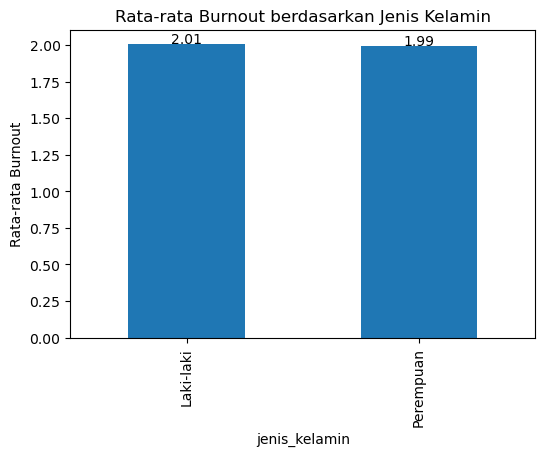

In [39]:
gender_burnout = (
    df.groupby('jenis_kelamin')['tingkat_burnout']
    .mean()
    .sort_values(ascending=False)
)

ax = gender_burnout.plot(
    kind='bar',
    figsize=(6,4)
)

for i, v in enumerate(gender_burnout):
    ax.text(i, v+0.01, f'{v:.2f}', ha='center')

plt.title('Rata-rata Burnout berdasarkan Jenis Kelamin')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory: Burnout laki-laki sebesar 2.01 dan perempuan 1.99. Perbedaannya sangat kecil.

2. Visualisasi kolom usia.

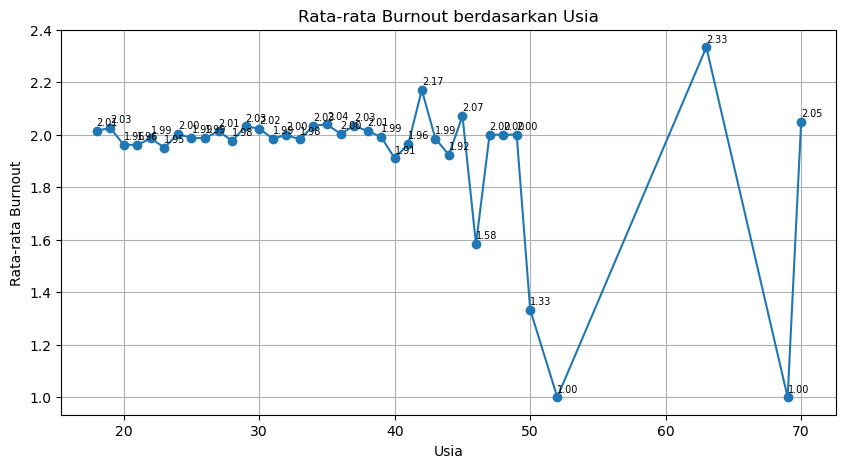

In [44]:
age_burnout = (
    df.groupby('usia')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    age_burnout['usia'],
    age_burnout['tingkat_burnout'],
    marker='o'
)

for x,y in zip(
    age_burnout['usia'],
    age_burnout['tingkat_burnout']
):
    plt.text(x,y+0.02,f'{y:.2f}',fontsize=7)

plt.title('Rata-rata Burnout berdasarkan Usia')
plt.xlabel('Usia')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Tidak terlihat pola peningkatan atau penurunan burnout yang konsisten berdasarkan usia. Pengaruh usia terhadap burnout relatif lemah.

3. Visualisasi kolom pendidikan terakhir.

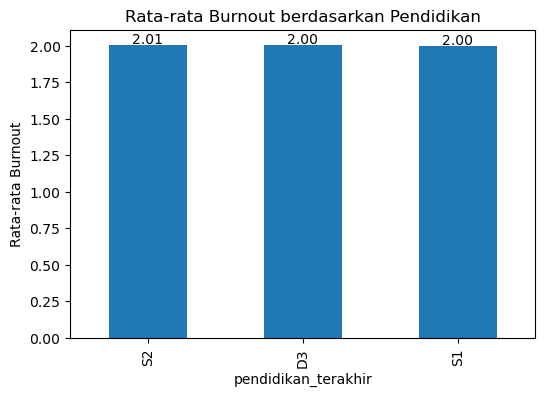

In [45]:
education_burnout = (
    df.groupby('pendidikan_terakhir')['tingkat_burnout']
    .mean()
    .sort_values(ascending=False)
)

ax = education_burnout.plot(
    kind='bar',
    figsize=(6,4)
)

for i,v in enumerate(education_burnout):
    ax.text(i,v+0.01,f'{v:.2f}',ha='center')

plt.title('Rata-rata Burnout berdasarkan Pendidikan')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Burnout D3, S1, dan S2 hampir sama. Tingkat pendidikan tidak menunjukkan pengaruh yang signifikan terhadap burnout.

4. Visualisasi kolom status pernikahan.

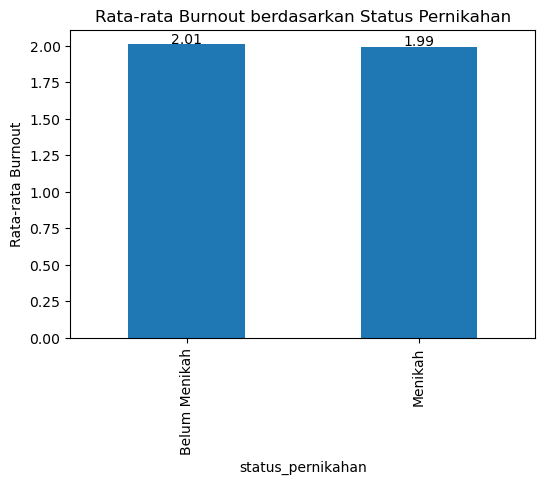

In [46]:
marital_burnout = (
    df.groupby('status_pernikahan')['tingkat_burnout']
    .mean()
    .sort_values(ascending=False)
)

ax = marital_burnout.plot(
    kind='bar',
    figsize=(6,4)
)

for i,v in enumerate(marital_burnout):
    ax.text(i,v+0.01,f'{v:.2f}',ha='center')

plt.title('Rata-rata Burnout berdasarkan Status Pernikahan')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Karyawan belum menikah memiliki burnout sedikit lebih tinggi. Namun, perbedaannya relatif kecil.

### Pertanyaan bisnis 2: Bagaimana departemen, tipe perusahaan, status WFH, dan lama bekerja memengaruhi tingkat burnout karyawan?

1. Visualisasi kolom departemen.

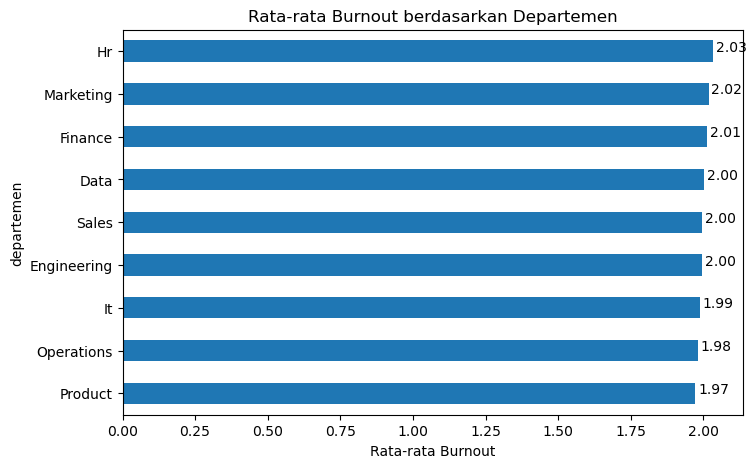

In [47]:
dept_burnout = (
    df.groupby('departemen')['tingkat_burnout']
    .mean()
    .sort_values()
)

ax = dept_burnout.plot(
    kind='barh',
    figsize=(8,5)
)

for i,v in enumerate(dept_burnout):
    ax.text(v+0.01,i,f'{v:.2f}')

plt.title('Rata-rata Burnout berdasarkan Departemen')
plt.xlabel('Rata-rata Burnout')
plt.show()

- Explanatory : Departemen HR memiliki burnout tertinggi. Product dan Operations memiliki burnout relatif lebih rendah.

2. Visualisasi kolom tipe perusahaan.

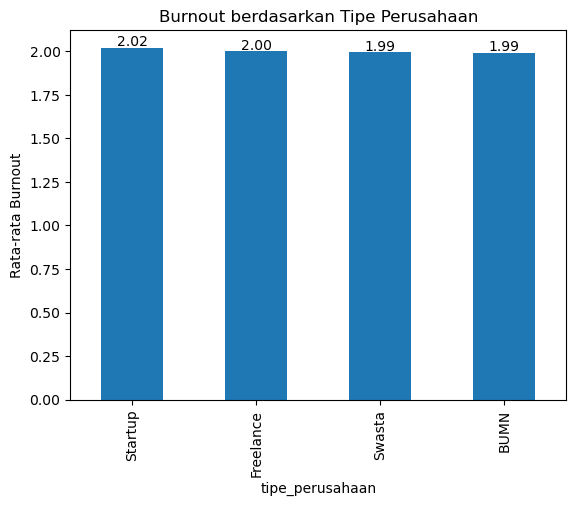

In [48]:
company_burnout = (
    df.groupby('tipe_perusahaan')['tingkat_burnout']
    .mean()
    .sort_values(ascending=False)
)

ax = company_burnout.plot(kind='bar')

for i,v in enumerate(company_burnout):
    ax.text(i,v+0.01,f'{v:.2f}',ha='center')

plt.title('Burnout berdasarkan Tipe Perusahaan')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Startup memiliki burnout tertinggi. Lingkungan kerja startup cenderung lebih dinamis.

3. Visualisasi kolom status WFH.

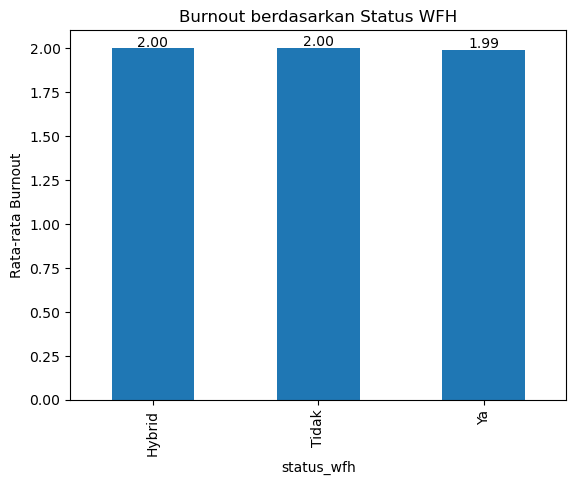

In [49]:
wfh_burnout = (
    df.groupby('status_wfh')['tingkat_burnout']
    .mean()
)

ax = wfh_burnout.plot(kind='bar')

for i,v in enumerate(wfh_burnout):
    ax.text(i,v+0.01,f'{v:.2f}',ha='center')

plt.title('Burnout berdasarkan Status WFH')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Burnout WFH sedikit lebih rendah dibanding hybrid maupun onsite.

4. Visualisasi kolom lama bekerja dalam tahun.

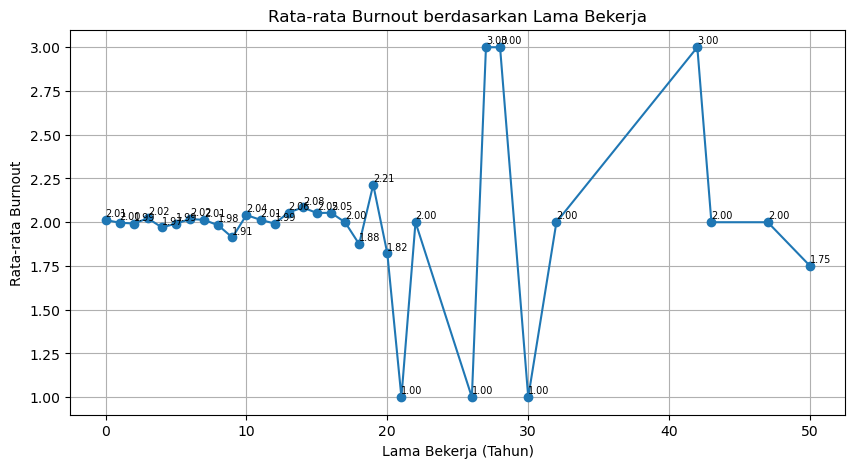

In [52]:
tenure_burnout = (
    df.groupby('lama_bekerja_tahun')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    tenure_burnout['lama_bekerja_tahun'],
    tenure_burnout['tingkat_burnout'],
    marker='o'
)

for x,y in zip(
    tenure_burnout['lama_bekerja_tahun'],
    tenure_burnout['tingkat_burnout']
):
    plt.text(x,y+0.02,f'{y:.2f}',fontsize=7)

plt.title('Rata-rata Burnout berdasarkan Lama Bekerja')
plt.xlabel('Lama Bekerja (Tahun)')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Tidak ditemukan tren yang konsisten. Lama bekerja bukan faktor dominan burnout.

### Pertanyaan bisnis 3: Apakah jam kerja, jam lembur, frekuensi meeting, jumlah deadline, konflik kerja, dan persepsi beban kerja berkaitan dengan meningkatnya burnout karyawan?

1. Visualisasi kolom jam kerja per hari.

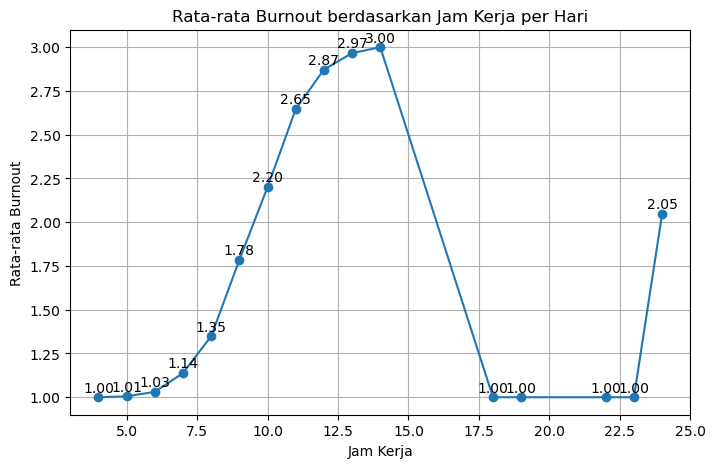

In [53]:
jam_kerja = (
    df.groupby('jam_kerja_per_hari')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    jam_kerja['jam_kerja_per_hari'],
    jam_kerja['tingkat_burnout'],
    marker='o'
)

for x,y in zip(
    jam_kerja['jam_kerja_per_hari'],
    jam_kerja['tingkat_burnout']
):
    plt.text(x,y+0.03,f'{y:.2f}',ha='center')

plt.title('Rata-rata Burnout berdasarkan Jam Kerja per Hari')
plt.xlabel('Jam Kerja')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Burnout meningkat secara konsisten seiring bertambahnya jam kerja. Karyawan yang bekerja lebih dari 10 jam per hari menunjukkan tingkat burnout yang sangat tinggi. Jam kerja merupakan salah satu faktor yang paling kuat memengaruhi burnout.

2. Visualisasi kolom jam lembur per hari.

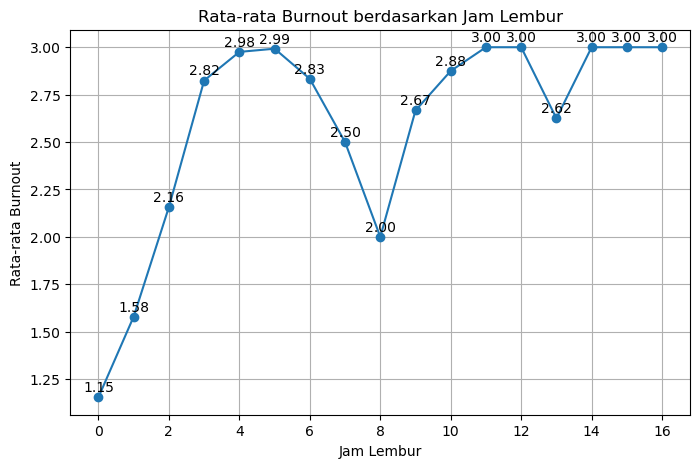

In [54]:
lembur = (
    df.groupby('jam_lembur_per_hari')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    lembur['jam_lembur_per_hari'],
    lembur['tingkat_burnout'],
    marker='o'
)

for x,y in zip(
    lembur['jam_lembur_per_hari'],
    lembur['tingkat_burnout']
):
    plt.text(x,y+0.03,f'{y:.2f}',ha='center')

plt.title('Rata-rata Burnout berdasarkan Jam Lembur')
plt.xlabel('Jam Lembur')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Burnout meningkat tajam ketika jam lembur bertambah. Burnout tertinggi ditemukan pada kelompok dengan lembur ekstrem.

3. Visualisasi kolom frekuensi meeting per hari.

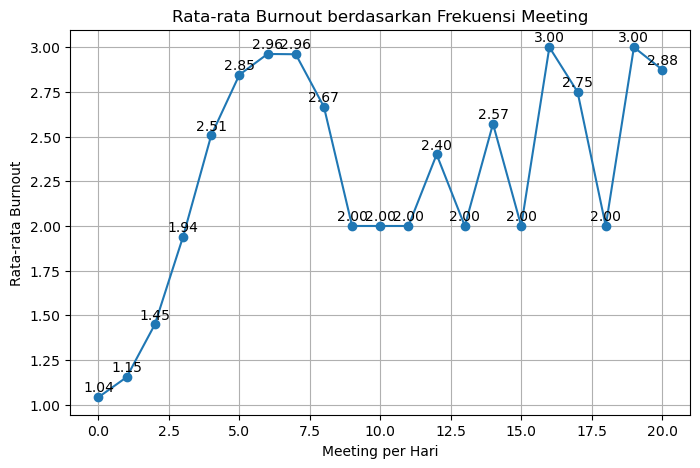

In [55]:
meeting = (
    df.groupby('frekuensi_meeting_per_hari')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    meeting['frekuensi_meeting_per_hari'],
    meeting['tingkat_burnout'],
    marker='o'
)

for x,y in zip(
    meeting['frekuensi_meeting_per_hari'],
    meeting['tingkat_burnout']
):
    plt.text(x,y+0.03,f'{y:.2f}',ha='center')

plt.title('Rata-rata Burnout berdasarkan Frekuensi Meeting')
plt.xlabel('Meeting per Hari')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Semakin banyak meeting yang harus dihadiri, burnout cenderung meningkat. Karyawan dengan lebih dari 5 meeting per hari menunjukkan burnout yang sangat tinggi.

4. Visualisasi kolom jumlah deadline per minggu.

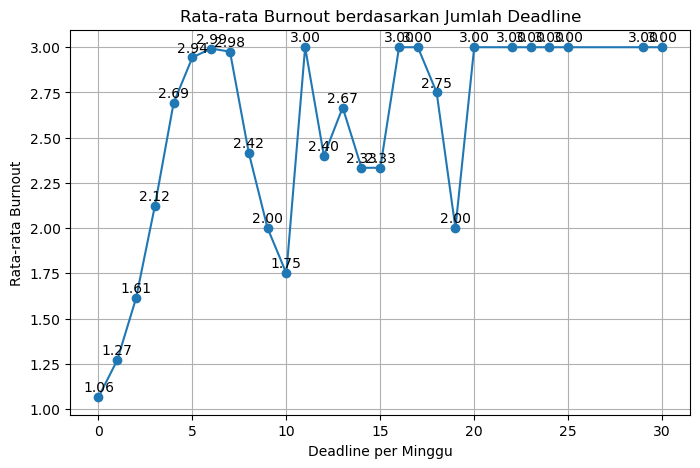

In [56]:
deadline = (
    df.groupby('jumlah_deadline_per_minggu')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    deadline['jumlah_deadline_per_minggu'],
    deadline['tingkat_burnout'],
    marker='o'
)

for x,y in zip(
    deadline['jumlah_deadline_per_minggu'],
    deadline['tingkat_burnout']
):
    plt.text(x,y+0.03,f'{y:.2f}',ha='center')

plt.title('Rata-rata Burnout berdasarkan Jumlah Deadline')
plt.xlabel('Deadline per Minggu')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Burnout meningkat hampir linear seiring bertambahnya jumlah deadline. Deadline merupakan salah satu sumber tekanan kerja utama.

5. Visualisasi kolom frekuensi konflik kerja.

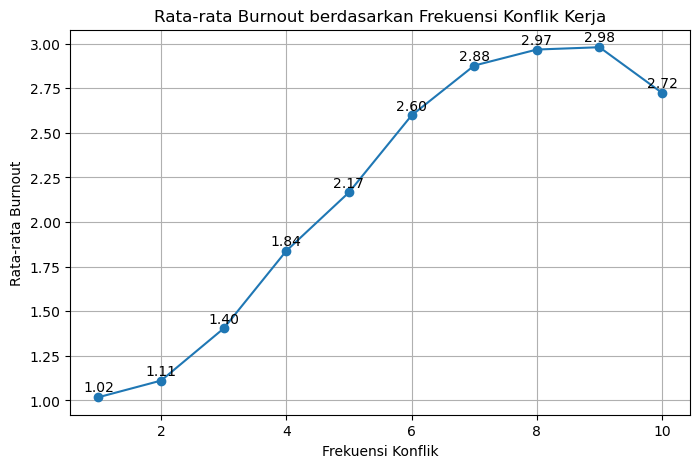

In [57]:
konflik = (
    df.groupby('frekuensi_konflik_kerja')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    konflik['frekuensi_konflik_kerja'],
    konflik['tingkat_burnout'],
    marker='o'
)

for x,y in zip(
    konflik['frekuensi_konflik_kerja'],
    konflik['tingkat_burnout']
):
    plt.text(x,y+0.03,f'{y:.2f}',ha='center')

plt.title('Rata-rata Burnout berdasarkan Frekuensi Konflik Kerja')
plt.xlabel('Frekuensi Konflik')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Konflik kerja memiliki hubungan positif yang sangat kuat dengan burnout. Semakin sering konflik terjadi, semakin tinggi tingkat burnout.

6. Visualisasi kolom persepsi beban kerja.

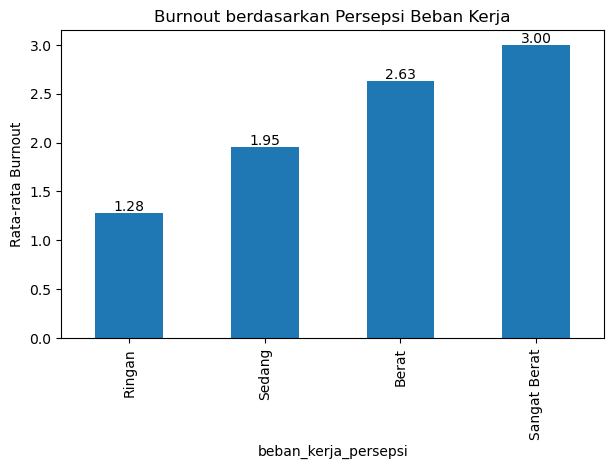

In [58]:
persepsi = (
    df.groupby('beban_kerja_persepsi')['tingkat_burnout']
    .mean()
    .sort_values()
)

ax = persepsi.plot(
    kind='bar',
    figsize=(7,4)
)

for i,v in enumerate(persepsi):
    ax.text(i,v+0.02,f'{v:.2f}',ha='center')

plt.title('Burnout berdasarkan Persepsi Beban Kerja')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Burnout meningkat seiring persepsi bahwa pekerjaan semakin berat. Kelompok dengan persepsi "Sangat Berat" memiliki burnout tertinggi.

### Pertanyaan bisnis 4: Bagaimana pola tidur, olahraga, penggunaan layar, dan kebiasaan merokok memengaruhi tingkat burnout karyawan?

1. Visualisasi kolom jam tidur.

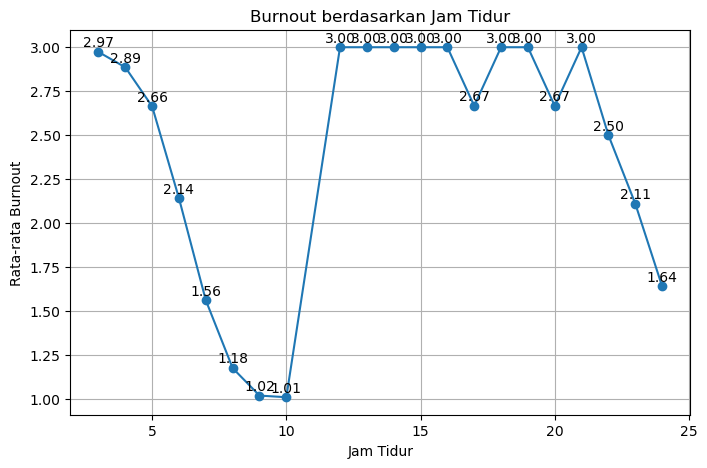

In [59]:
tidur = (
    df.groupby('jam_tidur_per_hari')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    tidur['jam_tidur_per_hari'],
    tidur['tingkat_burnout'],
    marker='o'
)

for x,y in zip(tidur['jam_tidur_per_hari'],tidur['tingkat_burnout']):
    plt.text(x,y+0.03,f'{y:.2f}',ha='center')

plt.title('Burnout berdasarkan Jam Tidur')
plt.xlabel('Jam Tidur')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Burnout tertinggi terjadi pada kelompok yang tidur kurang dari 5 jam dan lebih dari 10 jam. Burnout menurun ketika durasi tidur meningkat hingga sekitar 8–10 jam.

2. Visualisasi kolom kualitas tidur.

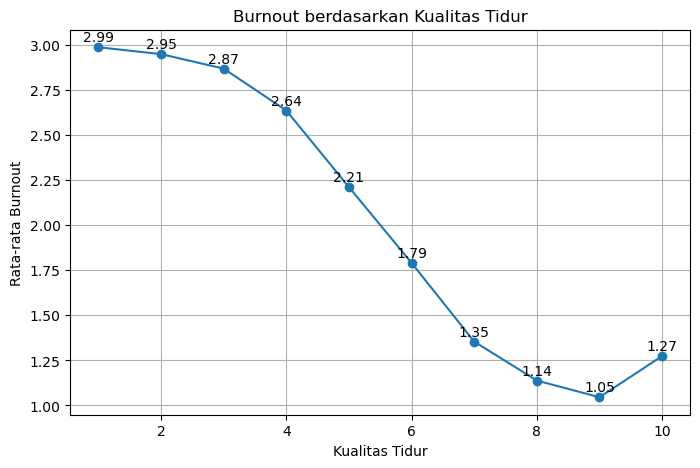

In [60]:
kualitas = (
    df.groupby('kualitas_tidur')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    kualitas['kualitas_tidur'],
    kualitas['tingkat_burnout'],
    marker='o'
)

for x,y in zip(kualitas['kualitas_tidur'],kualitas['tingkat_burnout']):
    plt.text(x,y+0.03,f'{y:.2f}',ha='center')

plt.title('Burnout berdasarkan Kualitas Tidur')
plt.xlabel('Kualitas Tidur')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Burnout menurun secara konsisten ketika kualitas tidur meningkat. Kualitas tidur merupakan faktor protektif terhadap burnout.

3. Visualisasi kolom frekuensi olahraga.

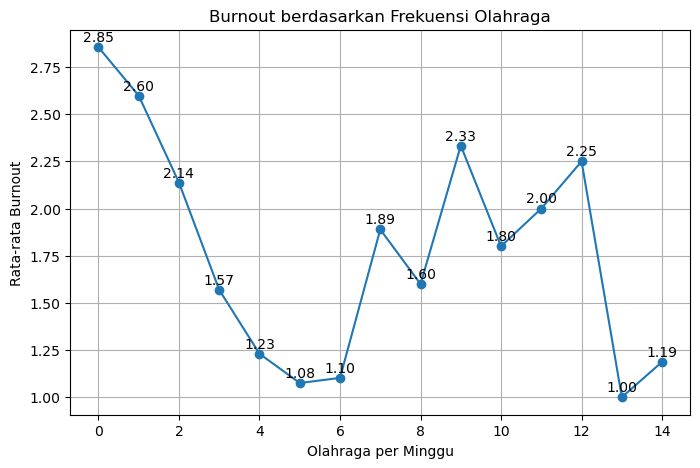

In [61]:
olahraga = (
    df.groupby('frekuensi_olahraga_per_minggu')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    olahraga['frekuensi_olahraga_per_minggu'],
    olahraga['tingkat_burnout'],
    marker='o'
)

for x,y in zip(
    olahraga['frekuensi_olahraga_per_minggu'],
    olahraga['tingkat_burnout']
):
    plt.text(x,y+0.03,f'{y:.2f}',ha='center')

plt.title('Burnout berdasarkan Frekuensi Olahraga')
plt.xlabel('Olahraga per Minggu')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Burnout cenderung menurun ketika frekuensi olahraga meningkat. Olahraga berpotensi membantu mengurangi burnout.

4. Visualisasi kolom jam layar per hari.

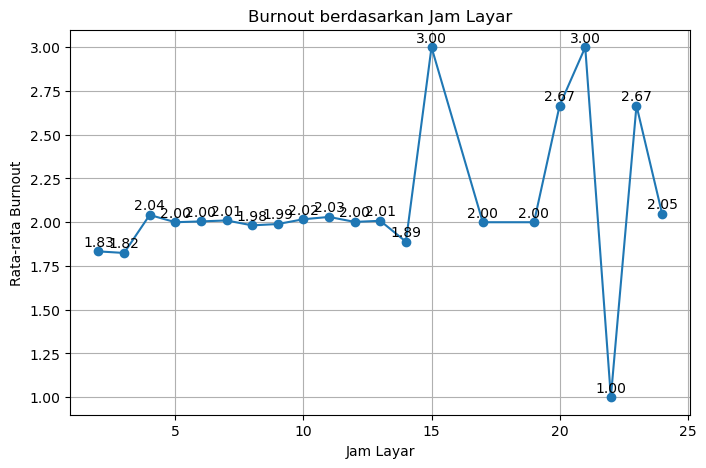

In [62]:
layar = (
    df.groupby('jam_layar_per_hari')['tingkat_burnout']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    layar['jam_layar_per_hari'],
    layar['tingkat_burnout'],
    marker='o'
)

for x,y in zip(layar['jam_layar_per_hari'],layar['tingkat_burnout']):
    plt.text(x,y+0.03,f'{y:.2f}',ha='center')

plt.title('Burnout berdasarkan Jam Layar')
plt.xlabel('Jam Layar')
plt.ylabel('Rata-rata Burnout')
plt.grid()
plt.show()

- Explanatory : Tidak terlihat pola yang konsisten antara jam layar dan burnout. Pengaruh jam layar relatif lebih lemah dibanding faktor pekerjaan.

5. Visualisasi kolom status merokok.

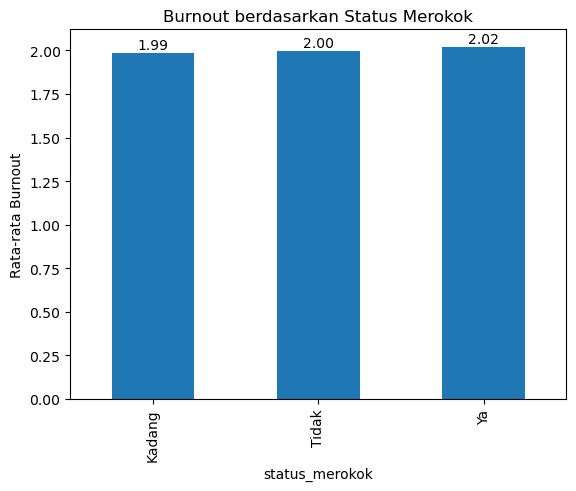

In [63]:
merokok = (
    df.groupby('status_merokok')['tingkat_burnout']
    .mean()
    .sort_values()
)

ax = merokok.plot(kind='bar')

for i,v in enumerate(merokok):
    ax.text(i,v+0.02,f'{v:.2f}',ha='center')

plt.title('Burnout berdasarkan Status Merokok')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Perbedaan burnout antar kelompok merokok relatif kecil. Merokok bukan faktor dominan dalam dataset ini.

### Pertanyaan bisnis 5: Bagaimana tingkat stres, kepuasan kerja, work-life balance, produktivitas diri, dukungan atasan, dan keamanan pekerjaan memengaruhi tingkat burnout karyawan?

1. Visualisasi kolom tingkat stres.

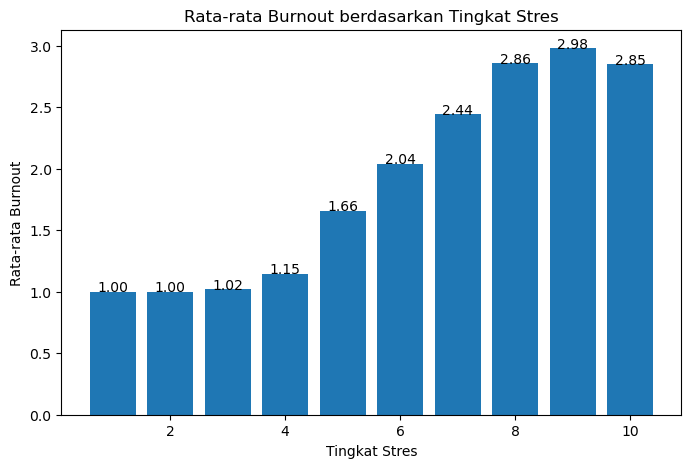

In [64]:
stress_burnout = df.groupby('tingkat_stres')['tingkat_burnout'].mean().reset_index()

plt.figure(figsize=(8,5))
bars = plt.bar(stress_burnout['tingkat_stres'],
               stress_burnout['tingkat_burnout'])

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.title('Rata-rata Burnout berdasarkan Tingkat Stres')
plt.xlabel('Tingkat Stres')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Burnout meningkat sangat tajam seiring naiknya tingkat stres. Pada tingkat stres 1–3, burnout berada di sekitar 1, sedangkan pada tingkat stres 8–10 burnout mendekati nilai maksimum yaitu 3. Hal ini menunjukkan bahwa stres merupakan faktor yang paling kuat memengaruhi burnout karyawan.

2. Visualisasi kolom kepuasan kerja.

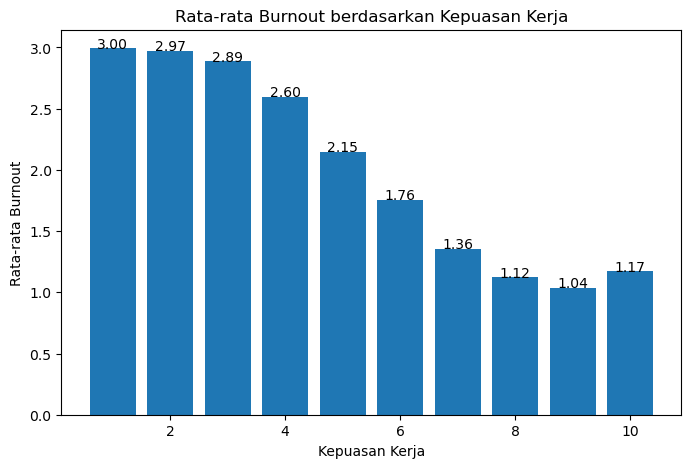

In [65]:
job_satisfaction = df.groupby(
    'kepuasan_kerja'
)['tingkat_burnout'].mean().reset_index()

plt.figure(figsize=(8,5))
bars = plt.bar(job_satisfaction['kepuasan_kerja'],
               job_satisfaction['tingkat_burnout'])

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.title('Rata-rata Burnout berdasarkan Kepuasan Kerja')
plt.xlabel('Kepuasan Kerja')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Burnout menurun secara konsisten ketika kepuasan kerja meningkat. Karyawan dengan kepuasan kerja rendah memiliki burnout hampir 3, sedangkan karyawan yang sangat puas memiliki burnout mendekati 1. Hasil ini menunjukkan bahwa kepuasan kerja berperan penting dalam menekan burnout.

3. Visualisasi kolom work life balance.

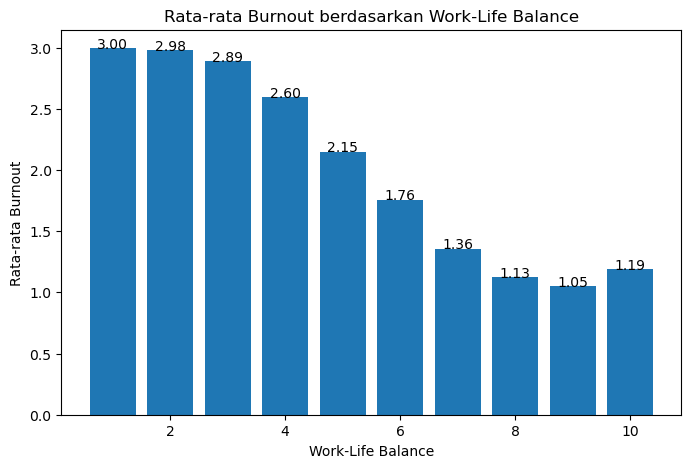

In [66]:
wlb = df.groupby(
    'work_life_balance'
)['tingkat_burnout'].mean().reset_index()

plt.figure(figsize=(8,5))
bars = plt.bar(wlb['work_life_balance'],
               wlb['tingkat_burnout'])

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.title('Rata-rata Burnout berdasarkan Work-Life Balance')
plt.xlabel('Work-Life Balance')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Semakin baik keseimbangan antara pekerjaan dan kehidupan pribadi, semakin rendah tingkat burnout. Burnout tertinggi ditemukan pada karyawan dengan work-life balance rendah dan terus menurun hingga mendekati 1 pada tingkat work-life balance yang tinggi.

4. Visualisasi kolom produktivitas diri.

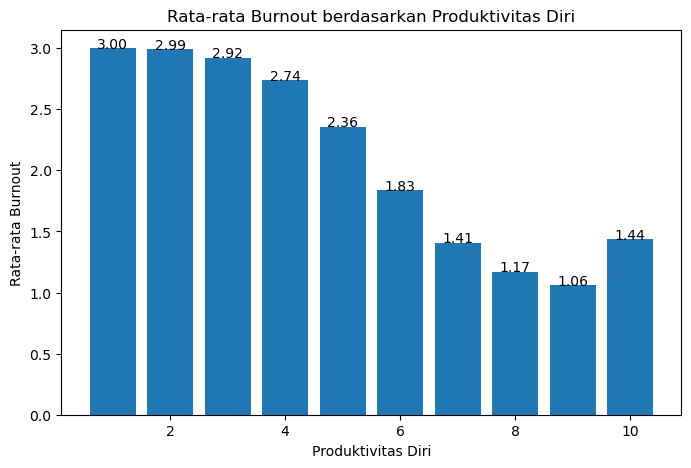

In [67]:
productivity = df.groupby(
    'produktivitas_diri'
)['tingkat_burnout'].mean().reset_index()

plt.figure(figsize=(8,5))
bars = plt.bar(productivity['produktivitas_diri'],
               productivity['tingkat_burnout'])

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.title('Rata-rata Burnout berdasarkan Produktivitas Diri')
plt.xlabel('Produktivitas Diri')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Burnout cenderung menurun ketika persepsi produktivitas diri meningkat. Karyawan yang merasa kurang produktif memiliki burnout lebih tinggi dibandingkan mereka yang merasa produktif. Hal ini mengindikasikan bahwa persepsi keberhasilan kerja berhubungan dengan kondisi psikologis yang lebih baik.

5. Visualisasi kolom dukungan atasan

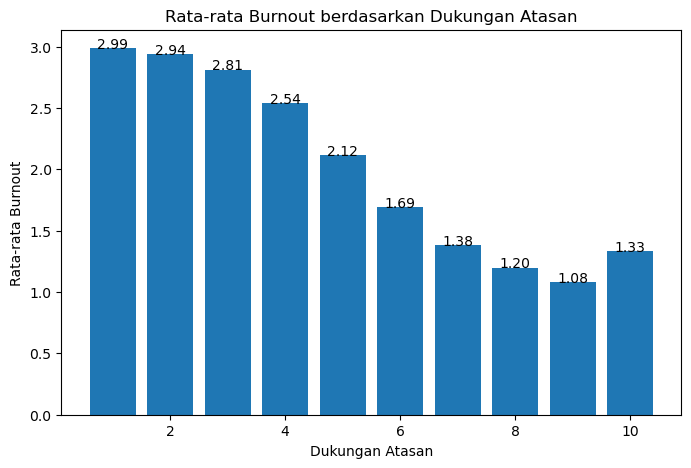

In [68]:
support = df.groupby(
    'dukungan_atasan'
)['tingkat_burnout'].mean().reset_index()

plt.figure(figsize=(8,5))
bars = plt.bar(support['dukungan_atasan'],
               support['tingkat_burnout'])

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.title('Rata-rata Burnout berdasarkan Dukungan Atasan')
plt.xlabel('Dukungan Atasan')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Burnout menurun seiring meningkatnya dukungan dari atasan. Karyawan yang merasa kurang didukung menunjukkan burnout yang jauh lebih tinggi dibandingkan mereka yang merasa memperoleh dukungan yang baik dari pimpinan.

6. Visualisasi kolom keamanan pekerjaan.

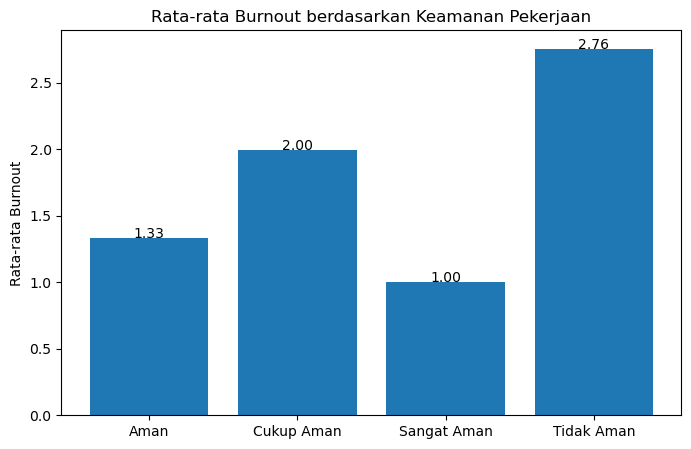

In [69]:
security = df.groupby(
    'keamanan_pekerjaan'
)['tingkat_burnout'].mean().reset_index()

plt.figure(figsize=(8,5))
bars = plt.bar(security['keamanan_pekerjaan'],
               security['tingkat_burnout'])

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.title('Rata-rata Burnout berdasarkan Keamanan Pekerjaan')
plt.ylabel('Rata-rata Burnout')
plt.show()

- Explanatory : Karyawan yang merasa pekerjaannya tidak aman memiliki tingkat burnout paling tinggi (2,76), sedangkan karyawan yang merasa aman memiliki burnout jauh lebih rendah. Rasa aman terhadap pekerjaan menjadi faktor penting dalam menjaga kesejahteraan psikologis karyawan.

### Pertanyaan bisnis 6: Apakah riwayat kesehatan mental dan keluhan fisik utama berkaitan dengan tingkat burnout karyawan?

1. Visualisasi kolom riwayat kesehatan mental.

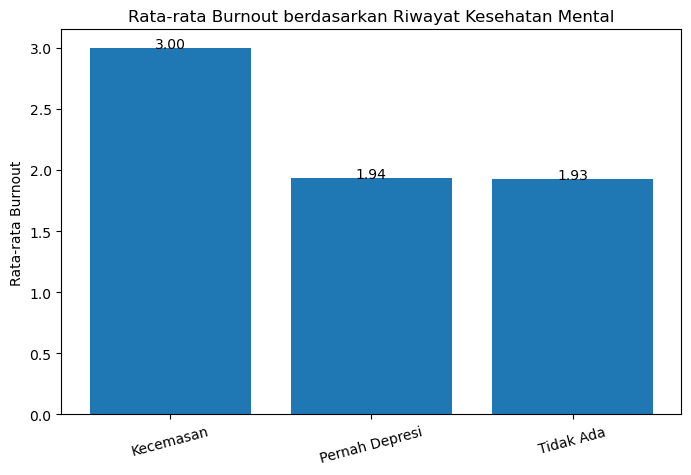

In [70]:
mental_history = df.groupby(
    'riwayat_kesehatan_mental'
)['tingkat_burnout'].mean().reset_index()

plt.figure(figsize=(8,5))
bars = plt.bar(
    mental_history['riwayat_kesehatan_mental'],
    mental_history['tingkat_burnout']
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.title('Rata-rata Burnout berdasarkan Riwayat Kesehatan Mental')
plt.ylabel('Rata-rata Burnout')
plt.xticks(rotation=15)
plt.show()

- Explanatory : Karyawan dengan riwayat kecemasan memiliki tingkat burnout tertinggi (3,00). Sementara itu, kelompok yang tidak memiliki riwayat gangguan kesehatan mental maupun yang pernah mengalami depresi menunjukkan tingkat burnout yang lebih rendah. Temuan ini mengindikasikan bahwa kondisi kecemasan memiliki hubungan yang kuat dengan burnout.

2. Visualisasi kolom keluhan fisik utama.

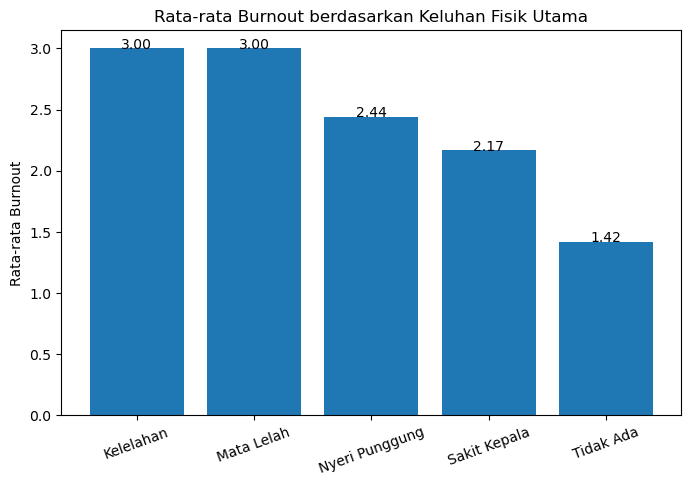

In [71]:
physical = df.groupby(
    'keluhan_fisik_utama'
)['tingkat_burnout'].mean().reset_index()

physical = physical.sort_values(
    by='tingkat_burnout',
    ascending=False
)

plt.figure(figsize=(8,5))
bars = plt.bar(
    physical['keluhan_fisik_utama'],
    physical['tingkat_burnout']
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.title('Rata-rata Burnout berdasarkan Keluhan Fisik Utama')
plt.ylabel('Rata-rata Burnout')
plt.xticks(rotation=20)
plt.show()

- Explanatory : Burnout tertinggi ditemukan pada karyawan yang mengalami kelelahan dan mata lelah (3,00). Keluhan nyeri punggung dan sakit kepala juga menunjukkan burnout yang relatif tinggi. Sebaliknya, karyawan yang tidak memiliki keluhan fisik memiliki burnout paling rendah (1,42). Hasil ini menunjukkan bahwa gejala fisik dapat menjadi indikator penting munculnya burnout pada karyawan.